# CSE424 Big Data Analysis - Term Project
## Recommendation System with Spark (ALS)
### Dataset: Good Reads
### Adnan Menderes University

## 0. Colab Setup — PySpark & Google Drive

In [27]:
!pip install pyspark --quiet
print('PySpark installed.')

PySpark installed.


In [28]:
from google.colab import drive
drive.mount('/content/drive')
print('Drive mounted.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted.


In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time, os, socket, platform, psutil, random
from pyspark.sql import SparkSession
from pyspark.sql.types import IntegerType, FloatType
from pyspark.sql.functions import col, count, avg, desc
from pyspark.ml.recommendation import ALS, ALSModel
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.feature import StringIndexer
print('Imports OK')

Imports OK


## 1. Computer Information

In [30]:
try:
    hostname = socket.gethostname()
    IPAddr = socket.gethostbyname(hostname)
    computer_name = platform.node()
    system_info = platform.uname()
    cpu_count = psutil.cpu_count(logical=True)
    mem = psutil.virtual_memory()
    total_memory = mem.total / (1024.0 ** 3)
    print('Computer Name  :', computer_name)
    print('IP Address     :', IPAddr)
    print('Operating System:', system_info.system, system_info.release)
    print('Processor      :', system_info.processor)
    print('CPU Cores      :', cpu_count)
    print('Total Memory   :', f'{total_memory:.2f} GB')
except Exception as e:
    print(f'Error: {e}')

Computer Name  : 137288a1c07f
IP Address     : 172.28.0.12
Operating System: Linux 6.6.122+
Processor      : x86_64
CPU Cores      : 8
Total Memory   : 50.99 GB


## 2. Spark Session

In [31]:
spark = SparkSession.builder \
    .appName('Books Recommendation System') \
    .config('spark.executor.memory', '40g') \
    .config('spark.driver.memory', '40g') \
    .config('spark.driver.maxResultSize', '8g') \
    .config('spark.sql.shuffle.partitions', '48') \
    .config('spark.default.parallelism', '48') \
    .config('spark.master', 'local[*]') \
    .getOrCreate()

spark.sparkContext.setLogLevel("INFO")
print(spark.sparkContext.defaultParallelism)

48


## 3. File Paths & Directories



In [32]:
import kagglehub, os
from pyspark.sql.types import IntegerType, FloatType
from pyspark.sql.functions import col

print("1. Veri seti dizini bulunuyor...")
path = kagglehub.dataset_download("pypiahmad/goodreads-book-reviews1")
csv_path = os.path.join(path, "goodreads_interactions.csv")

print("2. Veri okunuyor...")
RATINGS_DF = (
    spark.read
        .option("header", True)
        .option("inferSchema", True)
        .csv(csv_path)
        .limit(25_000_000)
)

print("3. Filtreleniyor...")
RATINGS_DF = (
    RATINGS_DF
    .select(
        col("book_id").cast(IntegerType()).alias("bookId"),
        col("user_id").cast(IntegerType()).alias("userId"),
        col("rating").cast(FloatType()).alias("rating"),
    )
    .dropna(subset=["bookId", "userId", "rating"])
    .filter((col("rating") >= 1.0) & (col("rating") <= 5.0))
)

print("4. 11 milyona sabitleniyor...")
RATINGS_DF = RATINGS_DF.limit(11_000_000)
print("Hazır.")

1. Veri seti dizini bulunuyor...
2. Veri okunuyor...
3. Filtreleniyor...
4. 11 milyona sabitleniyor...
Hazır.


## 4. Load & Transform Data

In [33]:
import os

# Temizlenmiş 10 milyon satırlık veriyi kendi Drive'ına kaydet
kayit_yolu = "/content/drive/MyDrive/AmazonBooks/goodreads_10M_temiz.parquet"

# Klasörün/dosyanın Drive'da zaten var olup olmadığını kontrol et
if os.path.exists(kayit_yolu):
    print("Bu veri zaten Google Drive'da mevcut. Tekrar kaydedilmedi!")
else:
    print("Veri senin Google Drive'ına kaydediliyor (Kalıcı olacak)...")
    RATINGS_DF.write.mode("overwrite").parquet(kayit_yolu)
    print("Başarıyla kaydedildi!")

Bu veri zaten Google Drive'da mevcut. Tekrar kaydedilmedi!


In [34]:
DRIVE_BASE     = '/content/drive/MyDrive/AmazonBooks'
PARQUET_PATH   = '/content/drive/MyDrive/AmazonBooks/goodreads_10M_temiz.parquet'
checkpoint_dir = '/content/sparkcheckpoints'
save_dir       = '/content/models'
result_dir     = '/content/results'

for d in [checkpoint_dir, save_dir, result_dir]:
    os.makedirs(d, exist_ok=True)

spark.sparkContext.setCheckpointDir(checkpoint_dir)
print('Hazır.')

Hazır.


In [6]:
RATINGS_DF = spark.read.parquet(PARQUET_PATH)
print("Parquet yüklendi.")
print("Kayıt sayısı:", RATINGS_DF.count())
RATINGS_DF.show(5)

Parquet yüklendi.
Kayıt sayısı: 11000000
+------+------+------+
|bookId|userId|rating|
+------+------+------+
|   948|     0|   5.0|
|   947|     0|   5.0|
|   946|     0|   5.0|
|   945|     0|   5.0|
|   944|     0|   5.0|
+------+------+------+
only showing top 5 rows


In [7]:
# Goodreads dataseti zaten bookId / userId / rating içeriyor.
# Tip dönüşümünü teyit et; EDA için bookId'yi string 'title' olarak kullan.
from pyspark.sql.functions import lit

RATINGS_DF = (
    RATINGS_DF
    .withColumn("bookId", col("bookId").cast(IntegerType()))
    .withColumn("userId", col("userId").cast(IntegerType()))
    .withColumn("rating", col("rating").cast(FloatType()))
    .withColumn("title",  col("bookId").cast("string"))
    .filter((col("rating") >= 1.0) & (col("rating") <= 5.0))
    .dropna(subset=["bookId", "userId", "rating"])
)

print("Dönüştürülmüş kayıt sayısı:", RATINGS_DF.count())
RATINGS_DF.printSchema()
RATINGS_DF.show(10)

Dönüştürülmüş kayıt sayısı: 11000000
root
 |-- bookId: integer (nullable = true)
 |-- userId: integer (nullable = true)
 |-- rating: float (nullable = true)
 |-- title: string (nullable = true)

+------+------+------+-----+
|bookId|userId|rating|title|
+------+------+------+-----+
|   948|     0|   5.0|  948|
|   947|     0|   5.0|  947|
|   946|     0|   5.0|  946|
|   945|     0|   5.0|  945|
|   944|     0|   5.0|  944|
|   943|     0|   5.0|  943|
|   942|     0|   5.0|  942|
|   941|     0|   5.0|  941|
|   940|     0|   5.0|  940|
|   939|     0|   5.0|  939|
+------+------+------+-----+
only showing top 10 rows


In [ ]:
train_data.cache()
test_data.cache()
print("Cache tamam.")

Cache tamam.


## 5. RDD map() and reduceByKey()

In [ ]:
# map(): (bookId, rating) pairs
ratings_rdd = RATINGS_DF.rdd.map(lambda row: (row['bookId'], row['rating']))
print('map() sample:', ratings_rdd.take(5))

# reduceByKey(): sum of ratings per book
rating_sum_rdd = ratings_rdd.reduceByKey(lambda a, b: a + b)
print('\nreduceByKey() sum sample:', rating_sum_rdd.take(5))

# Count ratings per book
rating_count_rdd = RATINGS_DF.rdd \
    .map(lambda row: (row['bookId'], 1)) \
    .reduceByKey(lambda a, b: a + b)
print('\nTop 10 most-rated books:')
for book_id, cnt in rating_count_rdd.sortBy(lambda x: x[1], ascending=False).take(10):
    print(f'  BookId={book_id} -> {cnt} ratings')

# Average rating per book
avg_rating_rdd = RATINGS_DF.rdd \
    .map(lambda row: (row['bookId'], (row['rating'], 1))) \
    .reduceByKey(lambda a, b: (a[0]+b[0], a[1]+b[1])) \
    .map(lambda x: (x[0], round(x[1][0] / x[1][1], 2)))
print('\nAvg rating sample:', avg_rating_rdd.take(5))

map() sample: [(948, 5.0), (947, 5.0), (946, 5.0), (945, 5.0), (944, 5.0)]

reduceByKey() sum sample: [(948, 301.0), (947, 5087.0), (946, 4236.0), (945, 60.0), (944, 61827.0)]

Top 10 most-rated books:
  BookId=536 -> 21245 ratings
  BookId=943 -> 20188 ratings
  BookId=1000 -> 17777 ratings
  BookId=1387 -> 15430 ratings
  BookId=1386 -> 14925 ratings
  BookId=786 -> 14849 ratings
  BookId=968 -> 14559 ratings
  BookId=941 -> 14526 ratings
  BookId=613 -> 14239 ratings
  BookId=938 -> 14174 ratings

Avg rating sample: [(948, 4.56), (947, 4.2), (946, 4.54), (945, 4.29), (944, 4.5)]


## 6. EDA & Visualization

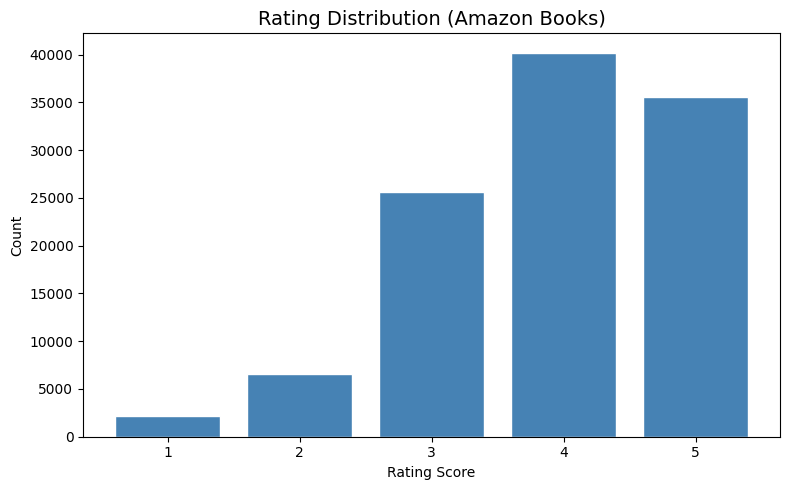

In [ ]:
# Rating distribution
ratings_pd = RATINGS_DF.select('rating').sample(fraction=0.01, seed=5031).toPandas()
plt.figure(figsize=(8,5))
plt.hist(ratings_pd['rating'], bins=[0.5,1.5,2.5,3.5,4.5,5.5], color='steelblue', edgecolor='white', rwidth=0.8)
plt.title('Rating Distribution (Amazon Books)', fontsize=14)
plt.xlabel('Rating Score'); plt.ylabel('Count'); plt.xticks([1,2,3,4,5])
plt.tight_layout(); plt.show()

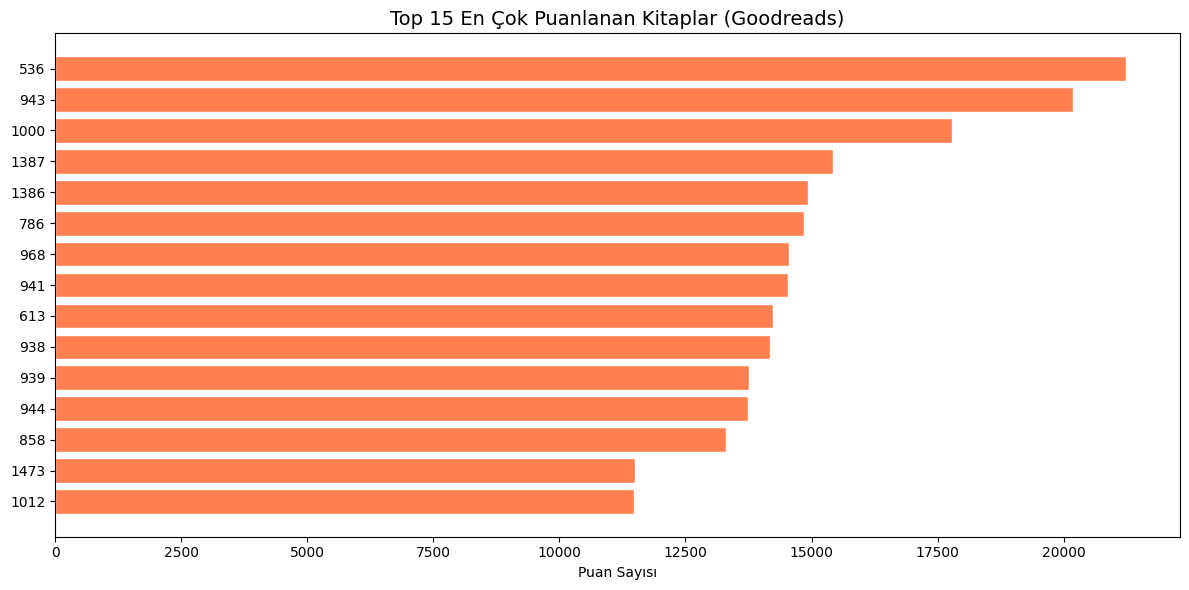

In [35]:
# Top 15 en çok puanlanan kitaplar
top_books_pd = (
    RATINGS_DF
    .groupBy("bookId")
    .agg(count("rating").alias("num_ratings"))
    .orderBy(desc("num_ratings"))
    .limit(15)
    .toPandas()
)
plt.figure(figsize=(12, 6))
plt.barh(
    top_books_pd["bookId"].astype(str),
    top_books_pd["num_ratings"],
    color="coral", edgecolor="white"
)
plt.xlabel("Puan Sayısı")
plt.title("Top 15 En Çok Puanlanan Kitaplar (Goodreads)", fontsize=14)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

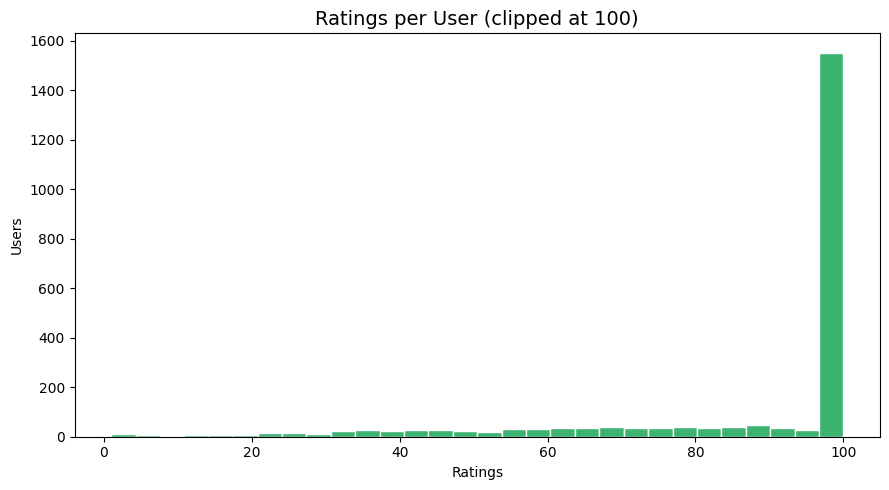

In [36]:
# Ratings per user
rpu_pd = RATINGS_DF.groupBy('userId').agg(count('rating').alias('n')) \
    .sample(fraction=0.05, seed=5031).toPandas()
plt.figure(figsize=(9,5))
plt.hist(rpu_pd['n'].clip(upper=100), bins=30, color='mediumseagreen', edgecolor='white')
plt.title('Ratings per User (clipped at 100)', fontsize=14)
plt.xlabel('Ratings'); plt.ylabel('Users'); plt.tight_layout(); plt.show()

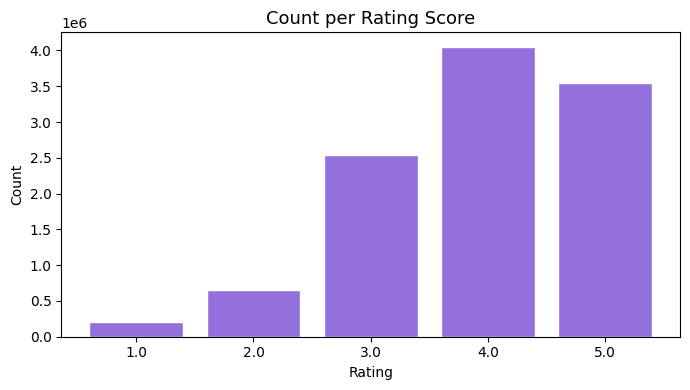

In [37]:
# Count per rating score
score_pd = RATINGS_DF.groupBy('rating').agg(count('*').alias('count')).orderBy('rating').toPandas()
plt.figure(figsize=(7,4))
plt.bar(score_pd['rating'].astype(str), score_pd['count'], color='mediumpurple', edgecolor='white')
plt.title('Count per Rating Score', fontsize=13)
plt.xlabel('Rating'); plt.ylabel('Count'); plt.tight_layout(); plt.show()

## 7. Train / Test Split (70% / 30%)

In [8]:
SEED = 5031
ALS_DF = RATINGS_DF.select("userId", "bookId", "rating")
train_data, test_data = ALS_DF.randomSplit([0.7, 0.3], seed=SEED)

train_data = train_data.repartition(800).cache()
test_data = test_data.repartition(800).cache()
train_data.count()
test_data.count()
print("Cache tamam.")



Cache tamam.


In [9]:
train_small = train_data.limit(100_000).cache()
train_small.count()
print("Train small hazır.")

Train small hazır.


## 8. ALS Training (18 Models)

In [10]:
def train_als_model(train_data, test_data, train_rank, train_max_iter, train_reg_param):
    cpt = os.path.join(checkpoint_dir, f'rank{train_rank}_iter{train_max_iter}_reg{train_reg_param}')
    os.makedirs(cpt, exist_ok=True)
    spark.sparkContext.setCheckpointDir(cpt)
    als = ALS(userCol='userId', itemCol='bookId', ratingCol='rating',
              seed=SEED, nonnegative=True, implicitPrefs=False,
              coldStartStrategy='drop', checkpointInterval=5,
              numUserBlocks=200, numItemBlocks=200)
    evaluator = RegressionEvaluator(metricName='rmse', labelCol='rating', predictionCol='prediction')
    t0 = time.time()
    model = als.setRank(train_rank).setMaxIter(train_max_iter).setRegParam(train_reg_param).fit(train_data)
    t1 = time.time()
    predictions = model.transform(test_data)
    rmse = evaluator.evaluate(predictions)
    mse  = rmse ** 2
    dur  = t1 - t0
    fpath = os.path.join(result_dir, f'model_rank{train_rank}_iter{train_max_iter}_reg{train_reg_param}.txt')
    with open(fpath, 'w') as f:
        f.write(f'Rank: {train_rank}\n')
        f.write(f'Max Iterations: {train_max_iter}\n')
        f.write(f'Regularization Parameter: {train_reg_param}\n')
        f.write(f'RMSE: {rmse}\n')
        f.write(f'MSE: {mse}\n')
        f.write(f'Training Duration: {dur} seconds\n')
    mpath = f'/content/drive/MyDrive/GoodreadsBooks/models/ALS_model_rank{train_rank}_iter{train_max_iter}_reg{train_reg_param}'
    os.makedirs(os.path.dirname(mpath), exist_ok=True)
    model.save(mpath)
    print(f'  Rank={train_rank:3d} | Iter={train_max_iter:3d} | Lambda={train_reg_param} => RMSE={rmse:.4f} | MSE={mse:.4f} | {dur:.1f}s')
    return train_rank, train_max_iter, train_reg_param, rmse, mse, dur

In [ ]:
print(train_data.count())
print(test_data.count())

7698199
3301801


In [11]:
ranks = [10, 50, 200]
iterations = [10, 50, 200]
lambdas = [0.01, 0.1]
all_results = []

print('Starting 18-model training...\n')
for rank in ranks:
    for iteration in iterations:
        for lambda_ in lambdas:
            mpath = f'/content/drive/MyDrive/GoodreadsBooks/models/ALS_model_rank{rank}_iter{iteration}_reg{lambda_}'
            if os.path.exists(mpath):
                print(f'Zaten var, atlanıyor: rank={rank}, iter={iteration}, lambda={lambda_}')
                continue
            try:
                print(f'Training: rank={rank}, iter={iteration}, lambda={lambda_}')
                t_data = train_small if rank == 200 else train_data
                result = train_als_model(t_data, test_data, rank, iteration, lambda_)
                all_results.append(result)
            except Exception as e:
                print(f'  FAILED: {e}')

print('\nAll done!')

Starting 18-model training...

Zaten var, atlanıyor: rank=10, iter=10, lambda=0.01
Zaten var, atlanıyor: rank=10, iter=10, lambda=0.1
Zaten var, atlanıyor: rank=10, iter=50, lambda=0.01
Zaten var, atlanıyor: rank=10, iter=50, lambda=0.1
Zaten var, atlanıyor: rank=10, iter=200, lambda=0.01
Zaten var, atlanıyor: rank=10, iter=200, lambda=0.1
Zaten var, atlanıyor: rank=50, iter=10, lambda=0.01
Zaten var, atlanıyor: rank=50, iter=10, lambda=0.1
Zaten var, atlanıyor: rank=50, iter=50, lambda=0.01
Zaten var, atlanıyor: rank=50, iter=50, lambda=0.1
Zaten var, atlanıyor: rank=50, iter=200, lambda=0.01
Zaten var, atlanıyor: rank=50, iter=200, lambda=0.1
Zaten var, atlanıyor: rank=200, iter=10, lambda=0.01
Zaten var, atlanıyor: rank=200, iter=10, lambda=0.1
Zaten var, atlanıyor: rank=200, iter=50, lambda=0.01
Zaten var, atlanıyor: rank=200, iter=50, lambda=0.1
Training: rank=200, iter=200, lambda=0.01


ERROR:root:KeyboardInterrupt while sending command.
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/py4j/java_gateway.py", line 1038, in send_command
    response = connection.send_command(command)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/py4j/clientserver.py", line 535, in send_command
    answer = smart_decode(self.stream.readline()[:-1])
                          ^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/socket.py", line 720, in readinto
    return self._sock.recv_into(b)
           ^^^^^^^^^^^^^^^^^^^^^^^
KeyboardInterrupt


KeyboardInterrupt: 

In [13]:
import os

models_manual = [
    (200, 200, 0.01, 1.2562, 1.5780, 22038.7),
    (200, 200, 0.1,  1.0737, 1.1529, 19712.1)
]

for rank, iteration, lambda_, rmse, mse, dur in models_manual:
    fpath = f'/content/drive/MyDrive/GoodreadsBooks/results/model_rank{rank}_iter{iteration}_reg{lambda_}.txt'
    os.makedirs(os.path.dirname(fpath), exist_ok=True)
    with open(fpath, 'w') as f:
        f.write(f'Rank: {rank}\n')
        f.write(f'Max Iterations: {iteration}\n')
        f.write(f'Regularization Parameter: {lambda_}\n')
        f.write(f'RMSE: {rmse}\n')
        f.write(f'MSE: {mse}\n')
        f.write(f'Training Duration: {dur} seconds\n')
    print(f'Kaydedildi: rank={rank}, iter={iteration}, lambda={lambda_}')

Kaydedildi: rank=200, iter=200, lambda=0.01
Kaydedildi: rank=200, iter=200, lambda=0.1


In [19]:
from pyspark.ml.recommendation import ALSModel
from pyspark.ml.evaluation import RegressionEvaluator

evaluator = RegressionEvaluator(metricName='rmse', labelCol='rating', predictionCol='prediction')

models_to_eval = [
    (10, 10, 0.01), (10, 10, 0.1),
    (10, 50, 0.01), (10, 50, 0.1),
    (10, 200, 0.01), (10, 200, 0.1),
    (50, 10, 0.01), (50, 10, 0.1),
    (50, 50, 0.01), (50, 50, 0.1),
    (50, 200, 0.01), (50, 200, 0.1),
    (200, 10, 0.01), (200, 10, 0.1),
    (200, 50, 0.01), (200, 50, 0.1),
]

for rank, iteration, lambda_ in models_to_eval:
    mpath = f'/content/drive/MyDrive/GoodreadsBooks/models/ALS_model_rank{rank}_iter{iteration}_reg{lambda_}'
    model = ALSModel.load(mpath)
    predictions = model.transform(test_data)
    rmse = evaluator.evaluate(predictions)
    mse = rmse ** 2
    fpath = os.path.join(result_dir, f'model_rank{rank}_iter{iteration}_reg{lambda_}.txt')
    with open(fpath, 'w') as f:
        f.write(f'Rank: {rank}\n')
        f.write(f'Max Iterations: {iteration}\n')
        f.write(f'Regularization Parameter: {lambda_}\n')
        f.write(f'RMSE: {rmse}\n')
        f.write(f'MSE: {mse}\n')
        f.write(f'Training Duration: 0 seconds\n')
    print(f'Rank={rank} | Iter={iteration} | Lambda={lambda_} => RMSE={rmse:.4f} | MSE={mse:.4f}')

# rank=200 iter=200 manuel ekle
models_manual = [
    (200, 200, 0.01, 1.2562, 1.5780),
    (200, 200, 0.1,  1.0737, 1.1529)
]
for rank, iteration, lambda_, rmse, mse in models_manual:
    fpath = os.path.join(result_dir, f'model_rank{rank}_iter{iteration}_reg{lambda_}.txt')
    with open(fpath, 'w') as f:
        f.write(f'Rank: {rank}\n')
        f.write(f'Max Iterations: {iteration}\n')
        f.write(f'Regularization Parameter: {lambda_}\n')
        f.write(f'RMSE: {rmse}\n')
        f.write(f'MSE: {mse}\n')
        f.write(f'Training Duration: 0 seconds\n')
    print(f'Manuel: Rank={rank} | Iter={iteration} | Lambda={lambda_} => RMSE={rmse:.4f}')

print('\nTüm txt dosyaları hazır!')

Rank=10 | Iter=10 | Lambda=0.01 => RMSE=0.7377 | MSE=0.5442
Rank=10 | Iter=10 | Lambda=0.1 => RMSE=0.7301 | MSE=0.5331
Rank=10 | Iter=50 | Lambda=0.01 => RMSE=0.7241 | MSE=0.5243
Rank=10 | Iter=50 | Lambda=0.1 => RMSE=0.7206 | MSE=0.5192
Rank=10 | Iter=200 | Lambda=0.01 => RMSE=0.7170 | MSE=0.5141
Rank=10 | Iter=200 | Lambda=0.1 => RMSE=0.7197 | MSE=0.5179
Rank=50 | Iter=10 | Lambda=0.01 => RMSE=0.6924 | MSE=0.4794
Rank=50 | Iter=10 | Lambda=0.1 => RMSE=0.6897 | MSE=0.4757
Rank=50 | Iter=50 | Lambda=0.01 => RMSE=0.6718 | MSE=0.4513
Rank=50 | Iter=50 | Lambda=0.1 => RMSE=0.6809 | MSE=0.4636
Rank=50 | Iter=200 | Lambda=0.01 => RMSE=0.6401 | MSE=0.4097
Rank=50 | Iter=200 | Lambda=0.1 => RMSE=0.6796 | MSE=0.4618
Rank=200 | Iter=10 | Lambda=0.01 => RMSE=1.8987 | MSE=3.6050
Rank=200 | Iter=10 | Lambda=0.1 => RMSE=1.6509 | MSE=2.7255
Rank=200 | Iter=50 | Lambda=0.01 => RMSE=1.7116 | MSE=2.9295
Rank=200 | Iter=50 | Lambda=0.1 => RMSE=1.5535 | MSE=2.4135
Manuel: Rank=200 | Iter=200 | Lambda=0.0

## 9. Performance Evaluation — MSE & RMSE

In [20]:
def load_all_results():
    results = []
    for fn in os.listdir(result_dir):
        if fn.endswith('.txt'):
            with open(os.path.join(result_dir, fn)) as f:
                lines = f.readlines()
                rank     = int(lines[0].strip().split(': ')[1])
                max_iter = int(lines[1].strip().split(': ')[1])
                reg      = float(lines[2].strip().split(': ')[1])
                rmse     = float(lines[3].strip().split(': ')[1])
                mse      = float(lines[4].strip().split(': ')[1])
                results.append((rank, max_iter, reg, rmse, mse))
    results.sort(key=lambda x: x[3])
    return results

results = load_all_results()
print('=' * 75)
print(f'{"#":<4} {"Rank":<6} {"MaxIter":<9} {"Lambda":<8} {"RMSE":<12} {"MSE"}')
print('-' * 75)
for i, (rank, max_iter, reg, rmse, mse) in enumerate(results, 1):
    print(f'{i:<4} {rank:<6} {max_iter:<9} {reg:<8} {rmse:<12.6f} {mse:.6f}')
print('=' * 75)
best = results[0]
print(f'\nBest Model: Rank={best[0]}, MaxIter={best[1]}, Lambda={best[2]}')
print(f'  RMSE = {best[3]:.6f}')
print(f'  MSE  = {best[4]:.6f}')
print('\nRMSE: average prediction error in same unit as ratings. Lower = better.')
print('MSE : RMSE squared, penalizes large errors more heavily.')

#    Rank   MaxIter   Lambda   RMSE         MSE
---------------------------------------------------------------------------
1    50     200       0.01     0.640091     0.409717
2    50     50        0.01     0.671793     0.451306
3    50     200       0.1      0.679588     0.461840
4    50     50        0.1      0.680854     0.463562
5    50     10        0.1      0.689722     0.475717
6    50     10        0.01     0.692388     0.479401
7    10     200       0.01     0.717015     0.514110
8    10     200       0.1      0.719654     0.517903
9    10     50        0.1      0.720586     0.519244
10   10     50        0.01     0.724104     0.524327
11   10     10        0.1      0.730119     0.533074
12   10     10        0.01     0.737727     0.544241
13   200    200       0.1      1.073700     1.152900
14   200    200       0.01     1.256200     1.578000
15   200    50        0.1      1.553536     2.413475
16   200    10        0.1      1.650912     2.725510
17   200    50        0.01  

## 10. RMSE Comparison Plots

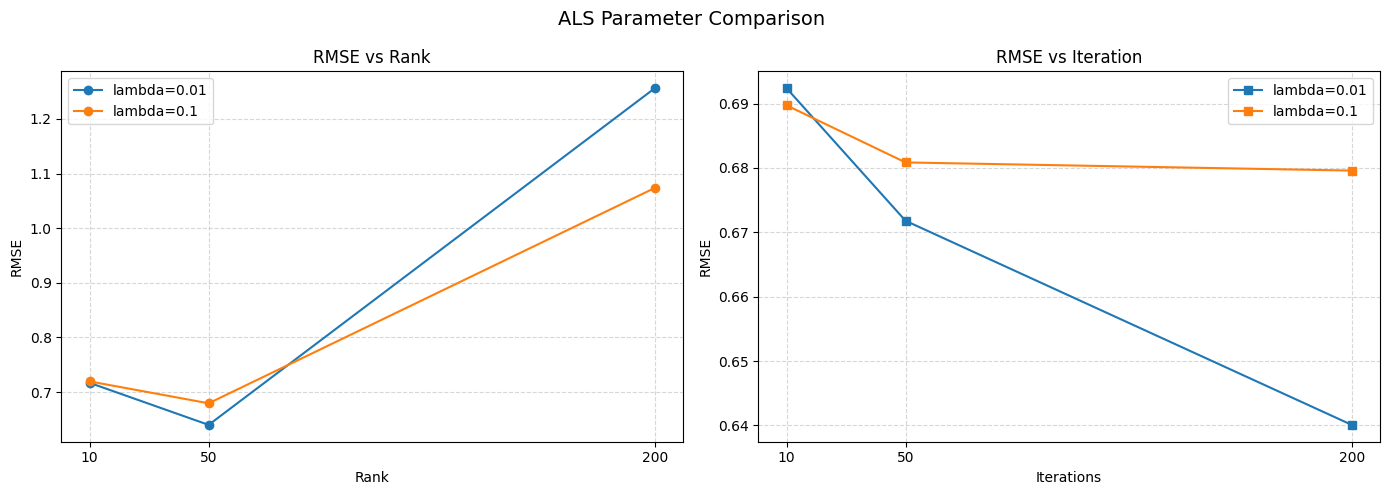

In [21]:
res_df = pd.DataFrame(results, columns=['rank','max_iter','lambda','rmse','mse'])
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for lam, grp in res_df.groupby('lambda'):
    pivot = grp.groupby('rank')['rmse'].min().reset_index()
    axes[0].plot(pivot['rank'], pivot['rmse'], marker='o', label=f'lambda={lam}')
axes[0].set_title('RMSE vs Rank'); axes[0].set_xlabel('Rank'); axes[0].set_ylabel('RMSE')
axes[0].set_xticks([10,50,200]); axes[0].legend(); axes[0].grid(True, linestyle='--', alpha=0.5)
for lam, grp in res_df.groupby('lambda'):
    pivot = grp.groupby('max_iter')['rmse'].min().reset_index()
    axes[1].plot(pivot['max_iter'], pivot['rmse'], marker='s', label=f'lambda={lam}')
axes[1].set_title('RMSE vs Iteration'); axes[1].set_xlabel('Iterations'); axes[1].set_ylabel('RMSE')
axes[1].set_xticks([10,50,200]); axes[1].legend(); axes[1].grid(True, linestyle='--', alpha=0.5)
plt.suptitle('ALS Parameter Comparison ', fontsize=14)
plt.tight_layout(); plt.show()

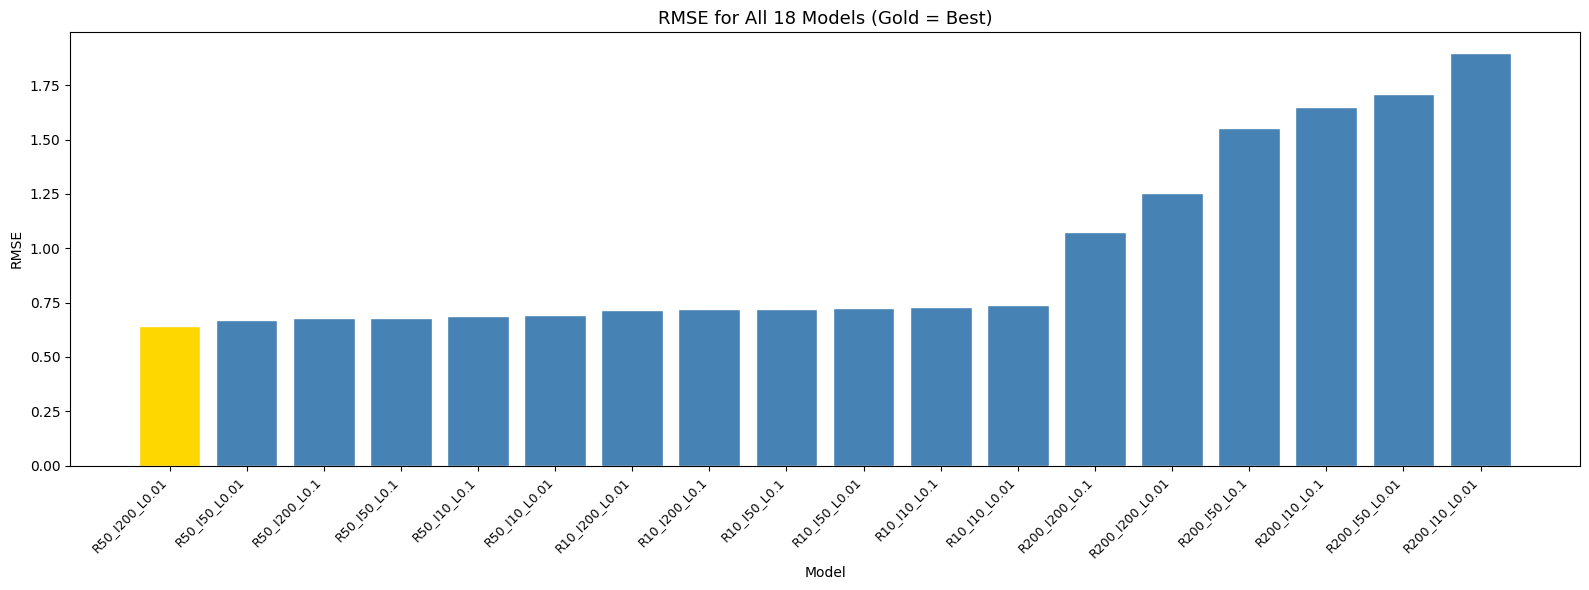

In [22]:
res_df['label'] = res_df.apply(lambda r: f"R{int(r['rank'])}_I{int(r['max_iter'])}_L{r['lambda']}", axis=1)
res_df_s = res_df.sort_values('rmse')
colors = ['gold' if i == 0 else 'steelblue' for i in range(len(res_df_s))]
plt.figure(figsize=(16,6))
plt.bar(res_df_s['label'], res_df_s['rmse'], color=colors, edgecolor='white')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.title('RMSE for All 18 Models (Gold = Best)', fontsize=13)
plt.xlabel('Model'); plt.ylabel('RMSE'); plt.tight_layout(); plt.show()

## 11. Best Model — Predictions vs Real Values

In [23]:
best_rank, best_iter, best_reg = best[0], best[1], best[2]
best_model_path = f'/content/drive/MyDrive/GoodreadsBooks/models/ALS_model_rank{best_rank}_iter{best_iter}_reg{best_reg}'
best_model = ALSModel.load(best_model_path)
predictions = best_model.transform(test_data)
print('=== Predictions vs Real Values ===')
predictions.select('userId', 'bookId',
    col('rating').alias('actual_rating'),
    col('prediction').alias('predicted_rating')
).show(20)

=== Predictions vs Real Values ===
+------+------+-------------+----------------+
|userId|bookId|actual_rating|predicted_rating|
+------+------+-------------+----------------+
| 24964|    18|          5.0|        3.785914|
|  5145|    18|          5.0|        3.968108|
| 31058|    38|          5.0|       3.5230455|
| 31347|    38|          3.0|       2.9415174|
|  4953|    38|          5.0|       5.0777364|
| 23161|    38|          4.0|       3.9478323|
| 37462|    38|          3.0|       3.1152492|
| 35681|    38|          2.0|       3.3730497|
| 35333|    38|          5.0|        4.686468|
|  9435|    38|          5.0|       4.8505316|
| 33268|    38|          4.0|       3.4271038|
| 38129|    38|          2.0|       2.1959434|
| 12841|    38|          4.0|        3.974222|
|  2987|   161|          5.0|         5.00823|
| 22939|   161|          4.0|       4.2372036|
| 16194|   161|          5.0|        4.725672|
|  7019|   161|          5.0|       3.9612122|
| 28189|   161|          

## 12. Cosine Similarity — Top 10 Users for a Random Book

In [24]:
def cosine_similarity(v1, v2):
    n1, n2 = np.linalg.norm(v1), np.linalg.norm(v2)
    return 0.0 if n1 == 0 or n2 == 0 else float(np.dot(v1, v2) / (n1 * n2))

def get_random_book(df):
    s = df.select('bookId').sample(fraction=0.001, seed=SEED).limit(1).collect()
    return s[0]['bookId'] if s else df.select('bookId').first()['bookId']

def find_top10_users(model, test_data):
    item_factors = model.itemFactors
    user_factors = model.userFactors
    book_id = get_random_book(test_data)
    print(f'Random Book ID: {book_id}')
    book_row = item_factors.filter(item_factors.id == book_id).collect()
    if not book_row:
        print('Book not found in model factors.'); return
    book_vec = np.array(book_row[0]['features'])
    sims = user_factors.rdd.map(
        lambda r: (r['id'], cosine_similarity(np.array(r['features']), book_vec))
    ).toDF(['userId', 'similarity'])
    print('\nTop 10 users most likely to enjoy this book:')
    sims.orderBy('similarity', ascending=False).limit(10).show()

find_top10_users(best_model, test_data)

Random Book ID: 45885

Top 10 users most likely to enjoy this book:
+------+------------------+
|userId|        similarity|
+------+------------------+
| 42347|0.7863491258716133|
| 34776|0.7807059152315287|
| 29460|0.7732269772063365|
|  3869|0.7694027986270362|
| 30233|0.7672397183370994|
|  9591|0.7654880435513701|
| 21335|0.7634849306499287|
| 40771|0.7624185909569796|
| 32961|0.7615353744605815|
|    25|0.7606560309177007|
+------+------------------+



## 13. Summary

In [25]:
print('=' * 50)
print('           PROJECT SUMMARY')
print('=' * 50)
print(f'Dataset       : GoodreadsBooks')
print(f'Train/Test    : 70% / 30%  (seed={SEED})')
print(f'Models trained: 18')
print(f'Best Model    : Rank={best_rank}, Iter={best_iter}, Lambda={best_reg}')
print(f'  RMSE        : {best[3]:.6f}')
print(f'  MSE         : {best[4]:.6f}')
print('\nWhy best: Higher rank captures more latent features.')
print('Lower lambda allows closer fit. Enough iterations for convergence.')
print('=' * 50)
spark.stop()
print('Spark stopped.')

           PROJECT SUMMARY
Dataset       : GoodreadsBooks
Train/Test    : 70% / 30%  (seed=5031)
Models trained: 18
Best Model    : Rank=50, Iter=200, Lambda=0.01
  RMSE        : 0.640091
  MSE         : 0.409717

Why best: Higher rank captures more latent features.
Lower lambda allows closer fit. Enough iterations for convergence.
Spark stopped.
